## ⏭ Problem Statement and Business Questions

### Problem Statement

To optimize sales performance and strategize for future growth, we need to comprehensively analyze the regional sales data from 2014 onwards. This analysis should identify key drivers of sales, uncover regional and product-specific performance disparities, evaluate the effectiveness of different sales channels, and benchmark actual sales against the 2017 budget to highlight areas for improvement and resource allocation.

### Business Questions

1.  **Sales Performance Overview:**
    *   What are the overall sales trends (revenue and quantity) over the years, months, and quarters?
    *   How do different sales channels (Wholesale, Distributor, Export) contribute to overall sales and revenue?
    *   What is the distribution of sales across different regions and states?

2.  **Product and Customer Analysis:**
    *   Which products are top-selling in terms of revenue and quantity?
    *   Are there any regional preferences for certain products?
    *   Who are the top customers by total purchase value and order frequency?

3.  **Regional Performance Deep Dive:**
    *   Which regions are consistently performing well, and which are underperforming?
    *   What factors might explain the differences in sales performance between regions (e.g., product mix, customer base, channel effectiveness)?

4.  **Budget vs. Actuals (for 2017):**
    *   How did actual sales performance in 2017 compare to the allocated budget?
    *   Which regions or products met, exceeded, or fell short of their 2017 budget targets?
    *   What insights can be drawn from the variances between budgeted and actual sales?

5.  **Profitability (if cost data is available):**
    *   What is the average profit margin per product and per order?
    *   Are there specific products, regions, or channels that are more profitable than others?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

all_sheets = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/slaes/Regional Sales Dataset.xlsx', sheet_name=None)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Sheets found in the Excel file:")
for sheet_name in all_sheets.keys():
    print(f"- {sheet_name}")

Sheets found in the Excel file:
- Sales Orders
- Customers
- Regions
- State Regions
- Products
- 2017 Budgets


In [ ]:
sale = all_sheets["Sales Orders"]
customer = all_sheets["Customers"]
product = all_sheets["Products"]
region = all_sheets["Regions"]
state_region = all_sheets["State Regions"]
budget_2017 = all_sheets['2017 Budgets']

In [ ]:
display(sale.head())
print("\n")
display(customer.head())
print("\n")
display(product.head())
print("\n")
display(region.head())
print("\n")
display(state_region.head())
print("\n")
display(budget_2017.head())

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


## Data Cleaning

In [ ]:
for sheet_name, sheet_data in all_sheets.items():
    print(f"Sheet: {sheet_name}")
    print(sheet_data.info())
    print("\n")

Sheet: Sales Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  floa

In [ ]:
for sheet_name, sheet_data in all_sheets.items():
    print(f"Sheet: {sheet_name}")
    print(sheet_data.duplicated().sum())

Sheet: Sales Orders
0
Sheet: Customers
0
Sheet: Regions
0
Sheet: State Regions
0
Sheet: Products
0
Sheet: 2017 Budgets
0


In [ ]:
state_region.columns = state_region.iloc[0]
state_region = state_region.drop(0)
state_region.head()

,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West
5,CO,Colorado,West


In [ ]:
df = sale.merge(customer, how='left', left_on="Customer Name Index", right_on="Customer Index")
df = df.merge(product, how='left', left_on="Product Description Index", right_on="Index")
df = df.merge(region, how='left', left_on="Delivery Region Index", right_on="id")
df = df.merge(state_region, how='left', left_on="state_code", right_on="State Code")
df = df.merge(budget_2017, how='left', left_on="Product Name", right_on="Product Name")

In [ ]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'State Code', 'State', 'Region', '2017 Budgets'],
      dtype='object')

In [ ]:
df = df.drop(columns=['Customer Name Index','Delivery Region Index','Product Description Index','Customer Index',"Index",'id','State Code','State','Currency Code', 'time_zone'])

In [ ]:
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [ ]:
df.rename(columns={'ordernumber':'order_number','orderdate':'order_date','name':'city_name', 'line_total':'revenue'},inplace=True)

In [ ]:
df.head()

,order_number,order_date,channel,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,product_name,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,region,2017_budgets
0,SO - 000225,2014-01-01,Wholesale,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,...,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,South,964940.231
1,SO - 0003378,2014-01-01,Distributor,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,...,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,Midwest,2067108.120
2,SO - 0005126,2014-01-01,Wholesale,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,...,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,West,5685138.270
3,SO - 0005614,2014-01-01,Export,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,...,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,Midwest,889737.555
4,SO - 0005781,2014-01-01,Wholesale,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,...,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,Northeast,1085037.329


In [ ]:
df.columns

Index(['order_number', 'order_date', 'channel', 'warehouse_code',
       'order_quantity', 'unit_price', 'revenue', 'total_unit_cost',
       'customer_names', 'product_name', 'city_name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'region',
       '2017_budgets'],
      dtype='object')

In [ ]:
df.loc[df['order_date'].dt.year != 2017,'2017_budgets'] = pd.NA

In [ ]:
df.sample(10)

,order_number,order_date,channel,warehouse_code,order_quantity,unit_price,revenue,total_unit_cost,customer_names,product_name,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,region,2017_budgets
5068,SO - 0001627,2014-04-30,Distributor,AXW291,10,3959.7,39597.0,3009.372,The Ltd,Product 16,...,34.02390,-118.17202,323,127610,31400,38766,19298247,11013,West,NaN
34823,SO - 0002650,2016-04-02,Distributor,GUT930,10,221.1,2211.0,170.247,Vitz Company,Product 26,...,40.72386,-74.23252,973,54580,20062,36782,7547773,5417,Northeast,NaN
58381,SO - 0004281,2017-10-16,Distributor,FLR025,7,3932.9,27530.3,1769.805,Zoonoodle Ltd,Product 21,...,32.80884,-83.69419,478,153515,57025,36568,645603627,14488557,South,959899.218
39060,SO - 000440,2016-07-11,Wholesale,NXH382,9,3892.7,35034.3,3075.233,True Ltd,Product 14,...,40.66871,-74.11431,551,66311,25474,54413,15077580,13644570,Northeast,NaN
17256,SO - 0008121,2015-02-12,Wholesale,FLR025,12,5226.0,62712.0,3240.120,Tagfeed Ltd,Product 2,...,42.98337,-78.87567,716,72937,32723,53760,48523623,3998029,Northeast,NaN
40142,SO - 0010309,2016-08-06,Wholesale,NXH382,11,1018.4,11202.4,824.904,Podcat Corp,Product 16,...,33.88168,-118.11701,562,78441,23176,48823,15845460,138188,West,NaN
33147,SO - 0009596,2016-02-22,Wholesale,FLR025,9,1829.1,16461.9,1225.497,Zava Group,Product 7,...,40.47811,-86.95599,765,64995,19942,33279,125995919,1183401,Midwest,NaN
54715,SO - 0002040,2017-07-21,Distributor,AXW291,6,1809.0,10854.0,1519.560,Internatio Company,Product 4,...,36.39559,-97.87839,580,51776,19531,46365,191541092,214073,South,2885560.824
35201,SO - 0005026,2016-04-11,Wholesale,NXH382,5,2566.1,12830.5,1950.236,Brightdog Corp,Product 8,...,48.75955,-122.48822,360,85146,33764,43536,71709769,6855426,West,NaN
62856,SO - 0010632,2018-01-30,Distributor,FLR025,9,1045.2,9406.8,836.160,Johnson Ltd,Product 4,...,41.04537,-73.63402,203,62695,22083,128153,123574542,50755176,Northeast,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   channel          64104 non-null  object        
 3   warehouse_code   64104 non-null  object        
 4   order_quantity   64104 non-null  int64         
 5   unit_price       64104 non-null  float64       
 6   revenue          64104 non-null  float64       
 7   total_unit_cost  64104 non-null  float64       
 8   customer_names   64104 non-null  object        
 9   product_name     64104 non-null  object        
 10  city_name        64104 non-null  object        
 11  county           64104 non-null  object        
 12  state_code       64104 non-null  object        
 13  state            64104 non-null  object        
 14  type             64104 non-null  objec

In [ ]:
df.describe()

,order_date,order_quantity,unit_price,revenue,total_unit_cost,latitude,longitude,area_code,population,households,median_income,land_area,water_area,2017_budgets
count,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,6.410400e+04,6.410400e+04,64104.000000,6.410400e+04,6.410400e+04,1.526300e+04
mean,2016-01-29 01:28:20.935979008,8.441689,2284.380803,19280.682937,1432.083899,37.769427,-94.247116,610.927945,1.590968e+05,5.702520e+04,59396.944325,1.278377e+08,1.287047e+07,2.989305e+06
min,2014-01-01 00:00:00,5.000000,167.500000,837.500000,68.675000,25.468720,-123.262040,202.000000,5.013800e+04,0.000000e+00,0.000000,2.575149e+06,0.000000e+00,5.944716e+05
25%,2015-01-13 00:00:00,6.000000,1031.800000,8019.900000,606.216000,33.953330,-112.034140,405.000000,6.106800e+04,2.263900e+04,43163.000000,4.865395e+07,2.807360e+05,1.672229e+06
50%,2016-01-27 00:00:00,8.000000,1855.900000,14023.100000,1084.495500,39.114170,-88.200900,626.000000,8.329800e+04,2.951800e+04,53587.500000,8.434784e+07,1.264402e+06,3.016489e+06
75%,2017-02-13 00:00:00,10.000000,3606.275000,27416.400000,2046.933750,41.676550,-80.407000,832.000000,1.286670e+05,4.540900e+04,71897.000000,1.283868e+08,4.850146e+06,3.925425e+06
max,2018-02-28 00:00:00,12.000000,6566.000000,78711.600000,5498.556000,48.759550,-70.255330,979.000000,8.550405e+06,3.113535e+06,149837.000000,1.935873e+09,8.521186e+08,5.685138e+06
std,NaN,2.276217,1663.598141,15429.602766,1107.705728,5.068599,16.884334,240.981103,3.997688e+05,1.437733e+05,21556.192739,1.783448e+08,5.804327e+07,1.557271e+06


## Feature Engineering

In [ ]:
# total cost
df['total_cost'] = df['order_quantity'] * df['total_unit_cost']

# profit
df['profit'] = df['revenue'] - df['total_cost']

# calculating profit margin percentage
df['profit_margin_percentage'] = (df['profit'] / df['revenue']) * 100

df['order_date'] = pd.to_datetime(df['order_date'])
df['month_name'] = df['order_date'].dt.month_name()
df['quarter'] = df['order_date'].dt.quarter
df['year'] = df['order_date'].dt.year


# Exploratory Data Analysis

### 🛍 Sales performance overview

## 1) Yearly Trend

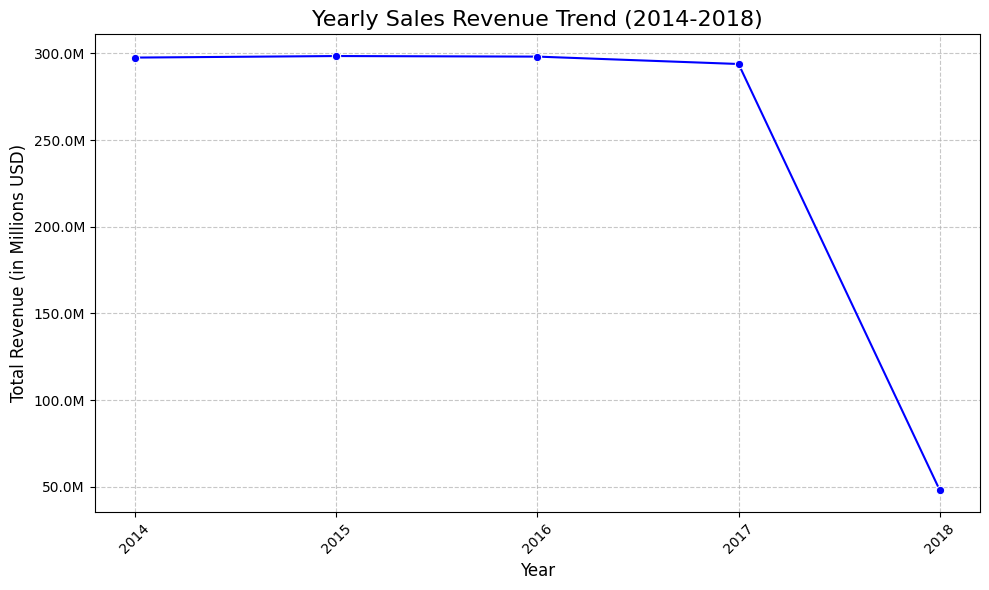

In [ ]:
# What are the overall sales trends (revenue and quantity) over the years, months, and quarters?
total_revenue_every_year = df.groupby('year')['revenue'].sum()

plt.figure(figsize=(10, 6))
sns.lineplot(x=total_revenue_every_year.index, y=total_revenue_every_year.values / 1000000, marker='o', color='blue')
plt.title('Yearly Sales Revenue Trend (2014-2018)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue (in Millions USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=total_revenue_every_year.index, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Format y-axis ticks to show 'M' for millions
plt.ticklabel_format(style='plain', axis='y') # Use plain style to avoid scientific notation before custom formatting

def millions_formatter(x, pos):
    return f'{x:.1f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

**Insights**:

*   Overall revenue remained relatively stable and consistent from 2014 to 2017, showing minimal fluctuation.
*   There was a significant decrease in total revenue in 2018 compared to previous years.
*   This suggests a potential market shift or operational change in early 2018 that impacted sales performance.

## 2) Monthly Trend

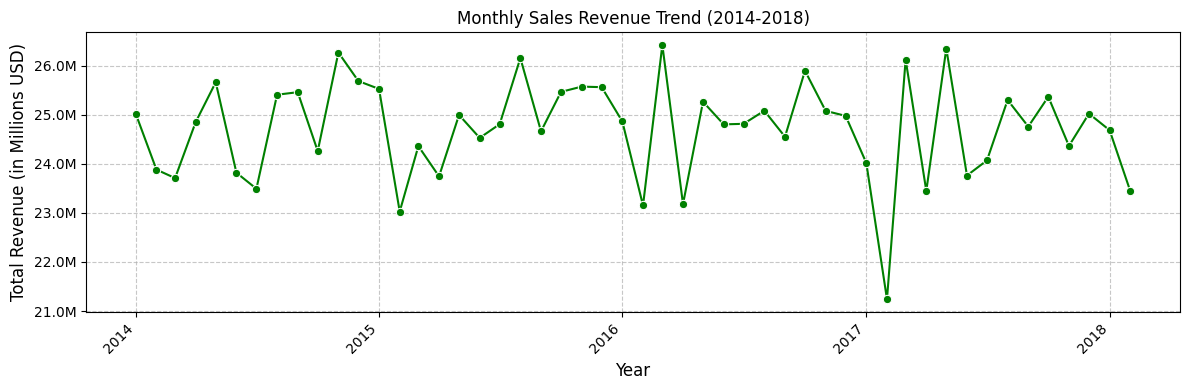

In [ ]:
import matplotlib.dates as mdates
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('order_month')['revenue'].sum()
plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_revenue.index.to_timestamp(), y=monthly_revenue.values/1000000, marker='o', color='green')
plt.title('Monthly Sales Revenue Trend (2014-2018)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue (in Millions USD)', fontsize=12)

# Set major ticks to display yearly
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
# Format major ticks to display only the year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

millions_formatter = lambda x, pos: f'{x:.1f}M'
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Insights**:

*   There are significant monthly fluctuations in total revenue across all years (2014-2018), indicating a lack of consistent month-over-month sales performance.
*   February 2017 stands out as having the lowest total revenue among all months from 2014 to 2018, suggesting a particular challenge or anomaly during that period.
*   While revenue fluctuates, many months demonstrate strong performance, with total revenue often exceeding $25M-$26M, indicating periods of high sales activity.
*   The overall decline in revenue observed in the yearly trend towards 2018 is also visible in the monthly data, particularly in the later months of 2017 and early 2018.

## 3) Channel Contribution

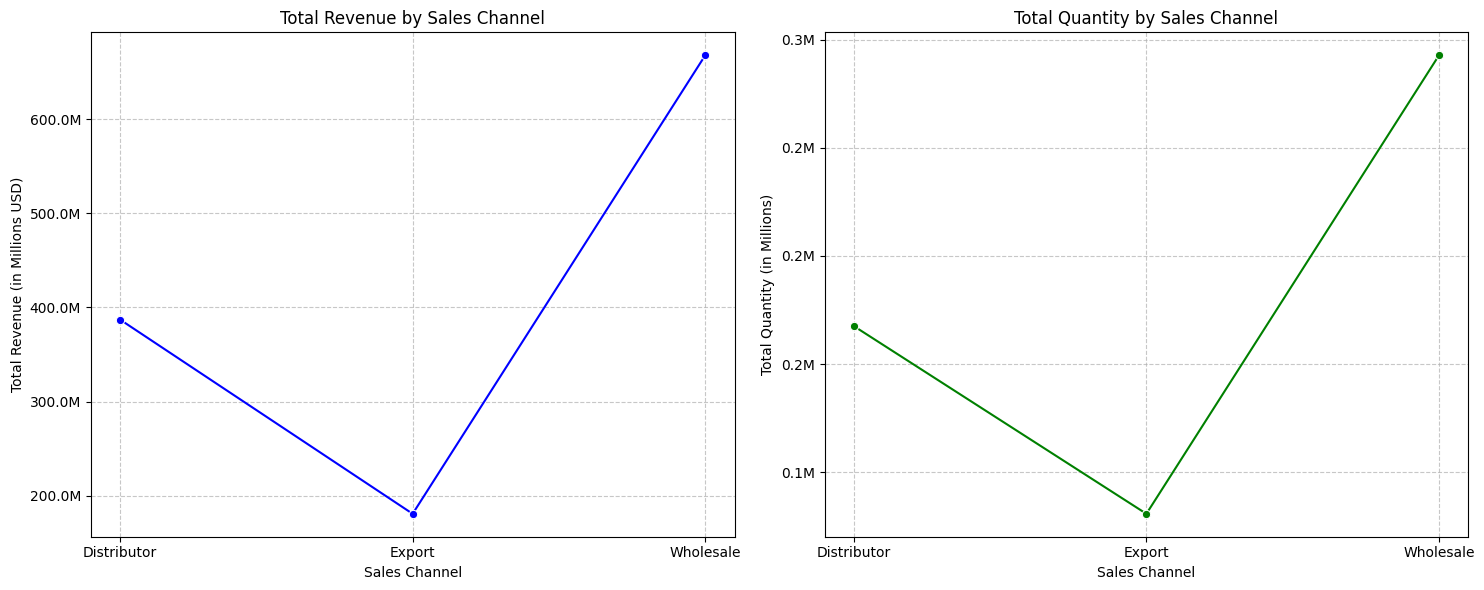

In [ ]:
# How do different sales channels (Wholesale, Distributor, Export) contribute to overall sales and revenue?
total_revenue_per_channel = df.groupby('channel')['revenue'].sum()
total_quantity_per_channel = df.groupby('channel')['order_quantity'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 1 row, 2 columns

# Plot for Revenue
sns.lineplot(x=total_revenue_per_channel.index, y=total_revenue_per_channel.values / 1000000, marker='o', color='blue', ax=axes[0])
axes[0].set_title('Total Revenue by Sales Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Total Revenue (in Millions USD)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Quantity
sns.lineplot(x=total_quantity_per_channel.index, y=total_quantity_per_channel.values / 1000000, marker='o', color='green', ax=axes[1])
axes[1].set_title('Total Quantity by Sales Channel')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Total Quantity (in Millions)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Format y-axis ticks for millions for both plots
millions_formatter = lambda x, pos: f'{x:.1f}M'
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

**Insights:**

*   The **Wholesale** channel consistently generates the highest total revenue, significantly outperforming other channels.
*   The **Distributor** channel ranks second in total revenue contribution, but it is substantially lower than Wholesale.
*   The **Export** channel consistently generates the lowest total revenue, indicating it is the least contributing channel.

## 4) Region Contribution

In [ ]:
# What is the distribution of sales by revenue across different regions and states?
region_revenue = df.groupby('region')['revenue'].sum()
state_revenue = df.groupby('state_code')['revenue'].sum().reset_index()

state_name_mapping = df[['state_code', 'state']].drop_duplicates()
state_revenue = state_revenue.merge(state_name_mapping, on='state_code', how='left')

import plotly.express as px

# Create a choropleth map
fig = px.choropleth(state_revenue,
                    locations='state_code',
                    locationmode="USA-states",
                    color='revenue',
                    color_continuous_scale="Viridis",
                    scope="usa",
                    title='Total Sales Revenue by State',
                    labels={'revenue':'Total Revenue'},
                    hover_name='state') # Show state name on hover

fig.show()

**Insights**:

*   California stands out as the state with the highest total sales revenue, significantly contributing to the overall sales performance.
*   The Western region, largely driven by California's sales, appears to be a strong revenue generator compared to other regions.
*   The choropleth map visually confirms the dominance of certain states in terms of sales revenue, indicating concentrated market strength.

## ✈ Customer Analysis

## 1) Top customers by revenue


/tmp/ipykernel_7031/3714987359.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




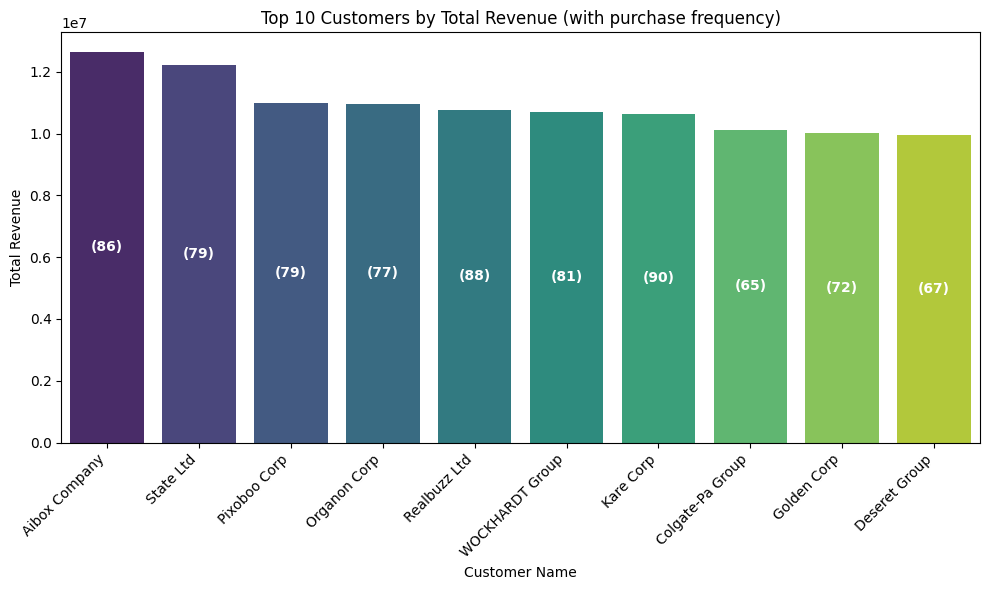

In [ ]:
customers_high_revenue_feq = df.groupby('customer_names').agg(total_revenue=('revenue', 'sum'),order_frequency=('order_number', 'nunique')).reset_index()
customers_high_revenue_feq = customers_high_revenue_feq.sort_values(by=['total_revenue','order_frequency'], ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='customer_names', y='total_revenue', data=customers_high_revenue_feq, palette='viridis')
plt.xlabel("Customer Name")
plt.ylabel("Total Revenue")
plt.title("Top 10 Customers by Total Revenue (with purchase frequency)")
plt.xticks(rotation=45, ha='right')

# Add order frequency in the center of each bar
for i, (index, row) in enumerate(customers_high_revenue_feq.iterrows()):
    plt.text(i, row['total_revenue'] / 2, f"({int(row['order_frequency'])})", color='white', ha="center", va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## RFM Analysis

In [ ]:
# Calculate Recency(how recently a customer made a purchase )
recency_df = df.groupby(by='customer_names', as_index=False)['order_date'].max()
recency_df['Recency'] = (df['order_date'].max() - recency_df['order_date']).dt.days

In [ ]:
# calculate frequency
frequency_df = df.groupby(by='customer_names', as_index=False)['order_number'].count()


In [ ]:
# Calculate Monetary Value
monetary_df = df.groupby(by='customer_names', as_index=False)['revenue'].sum()

In [ ]:
 # Merge Recency, Frequency and Monetary Data
 rfm_df = recency_df.merge(frequency_df, on='customer_names')
 rfm_df = rfm_df.merge(monetary_df, on='customer_names')

In [ ]:
# Rank Customers Based on Recency, Frequency and Monetary
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['order_number'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['revenue'].rank(ascending=True)

In [ ]:
# Normalize the Ranks
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

In [ ]:
# Drop Individual Ranks
rfm_df.drop(['R_rank', 'F_rank', 'M_rank'], axis=1, inplace=True)

In [ ]:
# Calculate RFM Score
r_weight, f_weight, m_weight = 0.5, 0.3, 0.2
rfm_df['Weighted_RFM_Score'] = (rfm_df['R_rank_norm'] * r_weight) + (rfm_df['F_rank_norm'] * f_weight) + (rfm_df['M_rank_norm'] * m_weight)
rfm_df.drop(columns=['R_rank_norm', 'F_rank_norm', 'M_rank_norm'], inplace=True)

In [ ]:
display(rfm_df[['customer_names', 'Weighted_RFM_Score']].head())

,customer_names,Weighted_RFM_Score
0,ALK-Abello Ltd,58.633800
1,Accord Group,29.808403
2,Accudial Company,34.227264
3,Actavis Company,80.028571
4,Aibox Company,62.970121


In [ ]:
# Segment Customers Based on RFM Score
def segment_customer(score):
    if score >= 80:
        return 'Platinum Customers'
    elif score >= 60:
        return 'Gold Customers'
    elif score >= 40:
        return 'Silver Customers'
    elif score >= 20:
        return 'Bronze Customers'
    else:
        return 'Churn Risk Customers'

# Apply the segmentation function
rfm_df['Customer_Segment'] = rfm_df['Weighted_RFM_Score'].apply(segment_customer)

# Display the count of customers in each segment
display(rfm_df['Customer_Segment'].value_counts())

,count
Customer_Segment,
Silver Customers,56
Gold Customers,45
Bronze Customers,35
Platinum Customers,25
Churn Risk Customers,14


## Top 5 Customers (highest RFM score)

In [ ]:
rfm_df[rfm_df['Customer_Segment'] == 'Platinum Customers'].sort_values(by='revenue', ascending=False).head(10)

,customer_names,order_date,Recency,order_number,revenue,Weighted_RFM_Score,Customer_Segment
101,Pixoboo Corp,2018-02-28,0,474,10986459.0,98.485714,Platinum Customers
106,Realbuzz Ltd,2018-02-27,1,528,10753299.0,88.913912,Platinum Customers
156,WOCKHARDT Group,2018-02-26,2,486,10701963.6,81.173483,Platinum Customers
72,Kare Corp,2018-02-26,2,540,10635633.6,81.830626,Platinum Customers
149,Vimbo Company,2018-02-27,1,462,9869863.8,86.513912,Platinum Customers
128,Skyble Corp,2018-02-28,0,450,9720279.6,96.228571,Platinum Customers
19,Bath Group,2018-02-28,0,420,9577529.4,93.971429,Platinum Customers
133,Talane Group,2018-02-28,0,516,9491662.2,97.971429,Platinum Customers
58,GOOD Ltd,2018-02-28,0,438,9147108.0,94.971429,Platinum Customers
76,Liberty Group,2018-02-28,0,408,8579524.2,91.371429,Platinum Customers


**Platinum Customers** (Score >= 80): Most valuable, loyal, and profitable customers.<br>
**Gold Customers** (Score >= 60): Highly valuable, strong purchasing behavior, potential for Platinum.<br>
**Silver Customers** (Score >= 40): Good, regular customers, steady contributors.<br>
**Bronze Customers** (Score >= 20): Show some engagement, potential for growth, or declining activity.<br>
**Churn Risk Customers** (Score < 20): Very low engagement, at risk of churning, need re-engagement.

## Regional Performance Deep Dive:

## 1) Regions performace

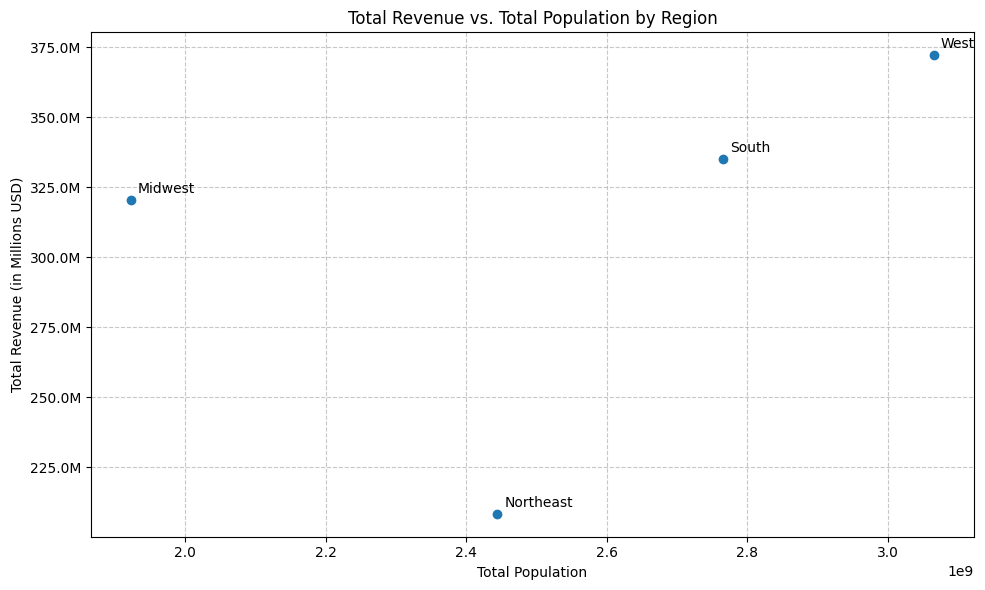

In [ ]:
# What factors might explain the differences in sales performance between regions (e.g., product mix, customer base, channel effectiveness)?
region_sales_pop = df.groupby('region').agg(total_revenue=('revenue', 'sum'), total_pop=('population', 'sum')).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(x=region_sales_pop['total_pop'], y=region_sales_pop['total_revenue'] / 1000000)

for i, row in region_sales_pop.iterrows():
    plt.annotate(row['region'], (row['total_pop'], row['total_revenue'] / 1000000), textcoords="offset points", xytext=(5, 5), ha='left')

plt.title('Total Revenue vs. Total Population by Region')
plt.xlabel('Total Population')
plt.ylabel('Total Revenue (in Millions USD)')
plt.grid(True, linestyle='--', alpha=0.7)

def millions_formatter(x, pos):
    return f'{x:.1f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Insights

1.  **Northeast Underperformance:** The Northeast region has a median population but exhibits very low revenue compared to other regions, suggesting potential inefficiencies or untapped market potential.
2.  **West Region Dominance:** The West region demonstrates the highest total population and also leads in total revenue, indicating a strong correlation between population size and sales performance in this region.
3.  **South and Midwest Performance:** The South and Midwest regions show moderate to high populations with corresponding revenue, but the West appears to be more revenue-efficient per unit of population compared to the South.

### Channel efficiency by region

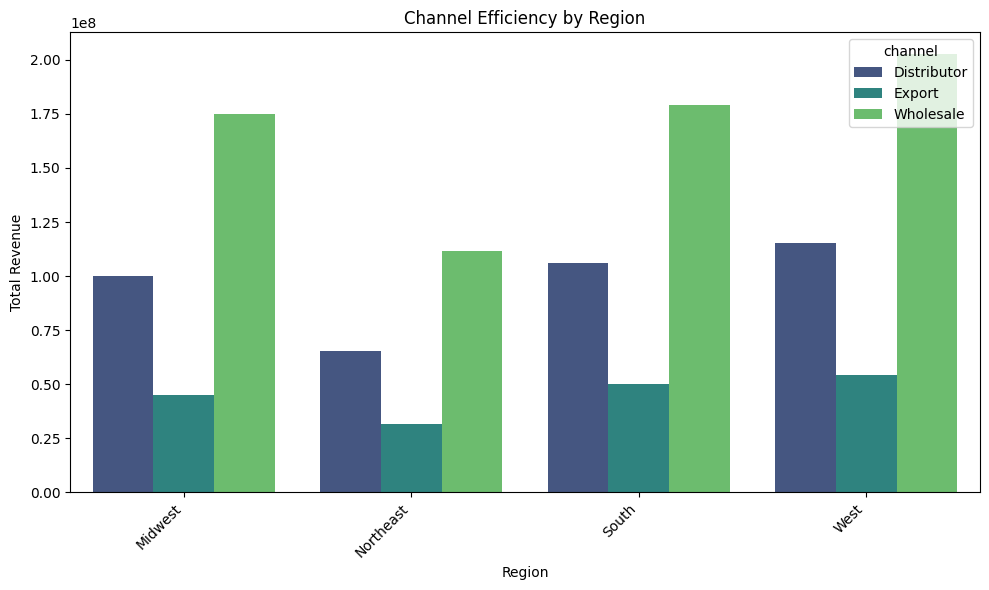

In [ ]:
channel_eff = df.groupby(['region', 'channel'],as_index=False)['revenue'].sum()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='region', y='revenue', hue='channel', data=channel_eff, palette='viridis')
sns.move_legend(ax, "upper right")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.title("Channel Efficiency by Region")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
*   Across all regions (Midwest, Northeast, South, and West), the **Wholesale channel consistently generates the highest revenue**, significantly outperforming both Distributor and Export channels.
*   Conversely, the **Export channel consistently yields the lowest revenue** in every region.
*   The Distributor channel ranks second in revenue contribution across all regions, but its performance is substantially lower than Wholesale.
*    Norteast region has lesser revenue

**Recommendations:**
*   **Capitalize on Wholesale Success:** Given that the majority of revenue in each region comes from the Wholesale channel, focus on strengthening and expanding this channel further. This could involve increasing product offerings, enhancing marketing efforts, or improving logistics within the Wholesale segment.
*   **Re-evaluate Export Strategy:** The low revenue from the Export channel suggests a need for re-evaluation. Investigate the reasons behind its underperformance, which could include market saturation, competitive pricing, inadequate marketing, or logistical challenges. Consider optimizing the product mix for export markets or exploring new international opportunities.
*   **Optimize Distributor Channel:** While performing better than Export, the Distributor channel still has room for improvement. Analyze its specific challenges and opportunities to enhance its revenue contribution.

## 2) Product Mix by region

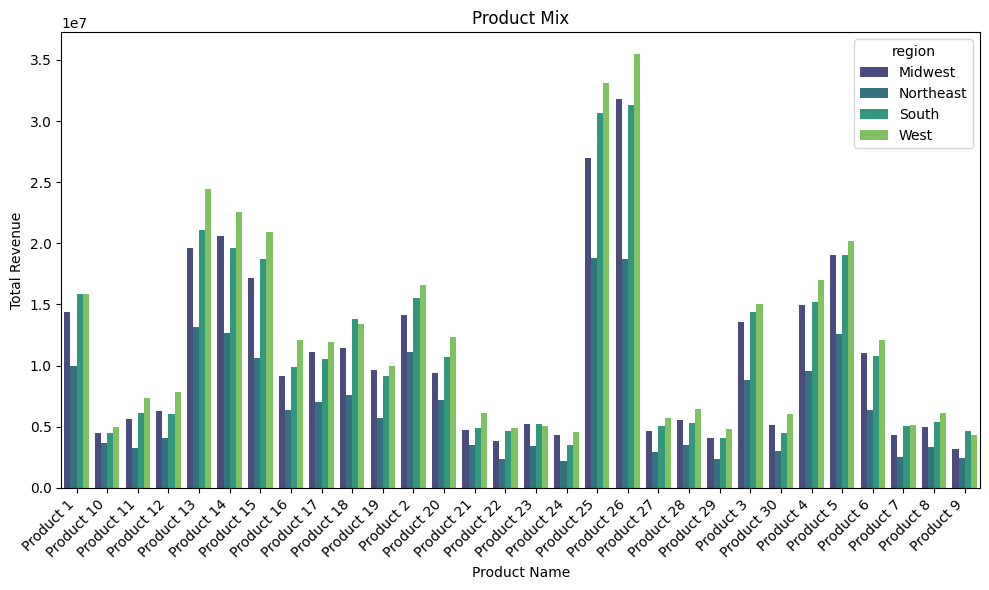

In [ ]:
product_mix = df.groupby(['region', 'product_name'], as_index=False)['revenue'].sum()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='product_name', y='revenue', hue='region', data=product_mix, palette='viridis')
sns.move_legend(ax, "upper right")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")
plt.title("Product Mix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# percentage Contribution of product 25 and 26
(df[df['product_name'] == 'Product 26']['revenue'].sum()/df['revenue'].sum())*100 + (df[df['product_name'] == 'Product 25']['revenue'].sum()/df['revenue'].sum())*100


np.float64(18.34720826579634)

### Product Mix by Region Insights and Recommendations

**Insights:**
*   **Dominant Products:** Product 26 and Product 25 are significant revenue drivers, together contributing approximately 18.35% to the total sales revenue across all regions. Their consistent high performance suggests strong market demand or effective sales strategies.
*   **Northeast Underperformance:** The Northeast region consistently shows lower revenue across almost all products compared to other regions. This indicates a broader regional challenge rather than issues with specific products within that region.

**Recommendations:**
*   **Leverage Top Performers (Products 25 & 26):** Continue to prioritize and invest in marketing and distribution efforts for Products 25 and 26. Explore opportunities to expand their reach, potentially through targeted campaigns or bundles in regions where they might be slightly underperforming relative to their overall potential.
*   **Deep Dive into Northeast Region:** Conduct a thorough analysis to understand the reasons behind the Northeast region's lower sales performance across all products. This could involve:
    *   **Market Research:** Understanding local consumer preferences, competitive landscape, and economic factors.
    *   **Channel Optimization:** Reviewing the effectiveness of sales channels specific to the Northeast. (This aligns with the previous insight about channel efficiency).
    *   **Marketing Strategy:** Developing region-specific marketing campaigns to boost product awareness and demand.
    *   **Product Fit:** Evaluating if the current product mix adequately addresses the needs and preferences of customers in the Northeast.
*   **Strategic Product Development:** Analyze the success factors of Products 25 and 26 to inform the development or marketing of other products, potentially applying similar strategies to boost their performance.

## 3) Budget vs Actual 2017

In [ ]:
df_2017 = df[df['year']==2017]
new_df = df_2017.groupby('product_name').agg(total_budgets=('2017_budgets', 'mean'), actual_revenue=('revenue', 'sum')).reset_index()

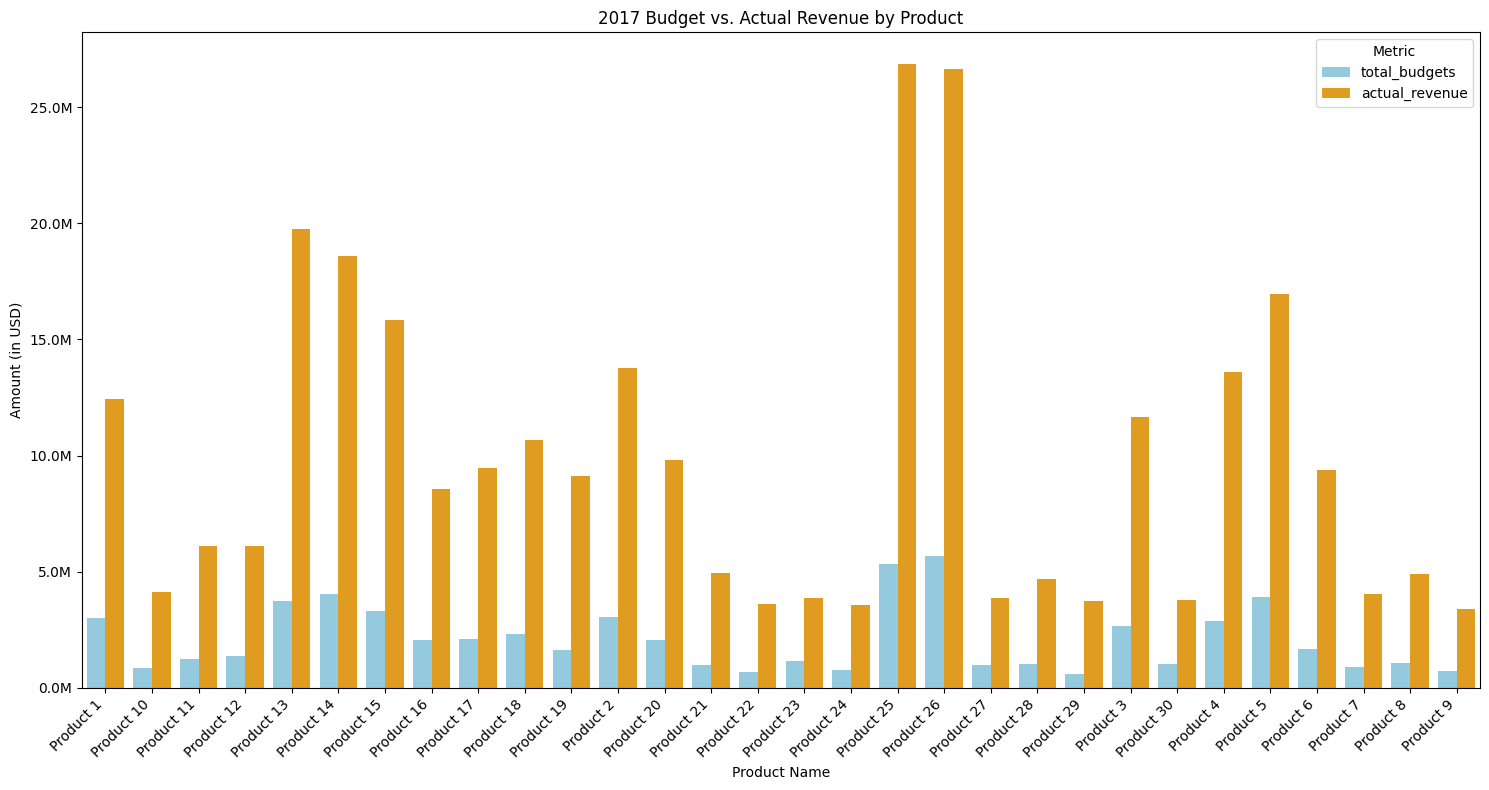

In [ ]:
# Reshape the DataFrame for grouped bar chart
new_df_melted = new_df.melt(id_vars=['product_name'], value_vars=['total_budgets', 'actual_revenue'], var_name='Metric', value_name='Amount')

plt.figure(figsize=(15, 8))
sns.barplot(data=new_df_melted, x='product_name', y='Amount', hue='Metric', palette={'total_budgets': 'skyblue', 'actual_revenue': 'orange'})
plt.xlabel('Product Name')
plt.ylabel('Amount (in USD)')
plt.title('2017 Budget vs. Actual Revenue by Product')
plt.xticks(rotation=45, ha='right')

# Format y-axis ticks to show 'M' for millions
def millions_formatter(x, pos):
    return f'{x/1000000:.1f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### 2017 Budget vs. Actuals Insights and Recommendations

**Insights:**
*   **Universal Overperformance:** All products consistently and significantly exceeded their allocated 2017 budget targets. This indicates a strong sales performance across the entire product portfolio for the year.
*   **Potential Budget Underestimation:** The substantial positive variance across all products suggests that the 2017 budget targets might have been conservatively set or underestimated the market demand and sales capabilities.
*   **Strong Market Demand/Effective Sales Strategies:** The widespread overperformance could be attributed to a generally favorable market environment, highly effective sales and marketing strategies, or high product demand in 2017.

**Recommendations:**
*   **Review Budgeting Process:** Re-evaluate the methodology for setting annual budgets. Incorporate historical performance data, market growth trends, and sales team feedback more rigorously to set more realistic and challenging targets that align with potential.
*   **Identify Success Factors:** Conduct a deeper analysis into the specific factors that contributed to such widespread overperformance in 2017. This could include successful marketing campaigns, product improvements, shifts in customer demand, or enhanced sales efficiency. Understanding these drivers can help replicate success in future years.
*   **Strategic Investment:** Given the strong performance, consider strategically investing more resources (e.g., increased production, expanded marketing, additional sales force) into these high-performing products to capitalize on their momentum and further boost revenue in subsequent years.
*   **Incentivize Performance:** While performance was strong, ensure that incentive structures are aligned to reward significant overperformance and motivate teams to continue striving for ambitious targets.

## Profitability Analysis

## 1) Product-Level Profitability

/tmp/ipykernel_7031/2246907255.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




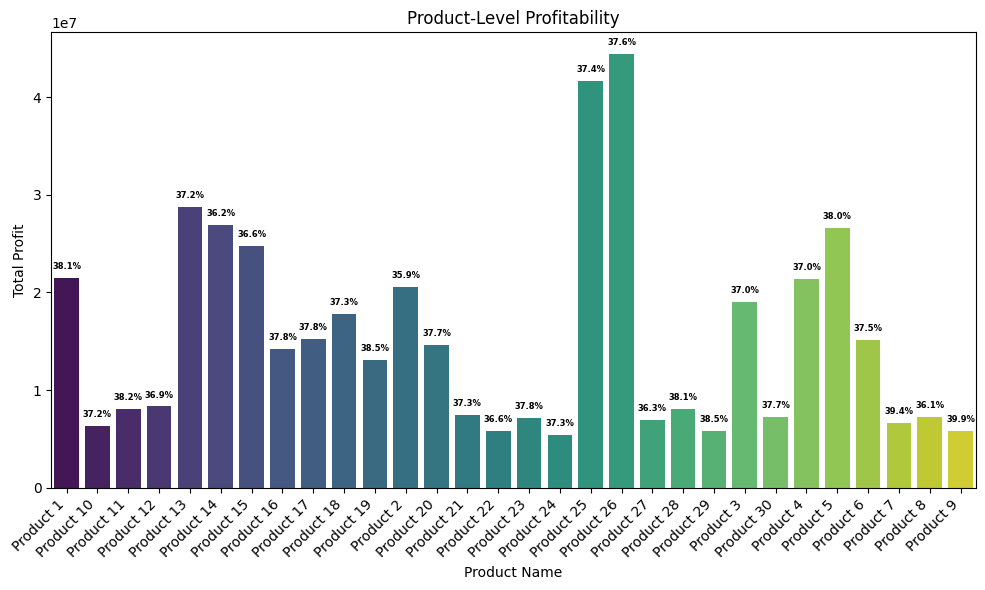

In [ ]:
product_profit = df.groupby('product_name').agg(total_profit=('profit', 'sum'), profit_margin_pct=('profit_margin_percentage','mean')).reset_index()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='product_name', y='total_profit', data=product_profit, palette='viridis')
for i, bar in enumerate(ax.patches):
    # Get the percentage value for the current product
    margin_val = product_profit['profit_margin_pct'].iloc[i]

    # Place text: x = bar center, y = bar height + small padding
    ax.annotate(f'{margin_val:.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom',
                fontsize=6, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')
plt.xlabel("Product Name")
plt.ylabel("Total Profit")
plt.title("Product-Level Profitability")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
product_profit

,product_name,total_profit,profit_margin_pct
0,Product 1,2.144745e+07,38.134298
1,Product 10,6.369469e+06,37.179310
2,Product 11,8.111384e+06,38.152047
3,Product 12,8.325595e+06,36.901639
4,Product 13,2.871081e+07,37.194529
5,Product 14,2.692773e+07,36.237947
6,Product 15,2.476014e+07,36.602273
7,Product 16,1.423927e+07,37.791277
8,Product 17,1.522378e+07,37.831884
9,Product 18,1.776175e+07,37.331412


### Product-Level Profitability Insights and Recommendations

**Insights:**
*   **Consistent Profit Margins:** A remarkable observation is the highly consistent profit margin percentage across almost all products, generally hovering between 37% and 39%. This suggests either a standardized pricing strategy relative to cost, uniform cost structures, or a combination of both.
*   **Revenue Drives Total Profit:** The total profit generated by each product is largely proportional to its total revenue. Products 26 and 25, which were identified earlier as top-selling products by revenue and quantity, also emerge as the highest contributors to total profit. This implies that while profit margins are stable, driving sales volume is the primary lever for increasing absolute profit.
*   **Impact of Resource Allocation:** As suggested, the high performance and resulting high profits of Products 25 and 26 could indeed be a result of strategic factors like higher budget allocation (marketing, development, etc.) over the years (2014-2018), leading to greater market penetration and sales volume.

**Recommendations:**
*   **Focus on Sales Volume:** Given the relatively uniform profit margins, the most direct path to increasing overall profitability is to boost sales volume across the board. Strategies should focus on market expansion, customer acquisition, and retention for all products.
*   **Strategic Investment in High Performers:** Continue to invest in and support Products 25 and 26, as they are proven profit drivers. Explore ways to maintain their market leadership and potentially expand their offerings or target new customer segments. These products serve as benchmarks for success.
*   **Investigate Underperforming Products:** For products with lower total profit but similar profit margins, analyze the reasons for their lower sales volume. This could involve reassessing marketing strategies, sales channels, or product positioning. The goal should be to elevate their sales performance to match their inherent profitability.
*   **Review Pricing/Cost Strategy (Optional):** If the business objective includes differentiating profitability across products or increasing overall margins, a deeper review of pricing strategies and cost structures for individual products might be necessary. This would involve examining opportunities for cost reduction or premium pricing for certain high-value products, provided market conditions allow.

## 2) Region level Profitability

/tmp/ipykernel_7031/1848747712.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




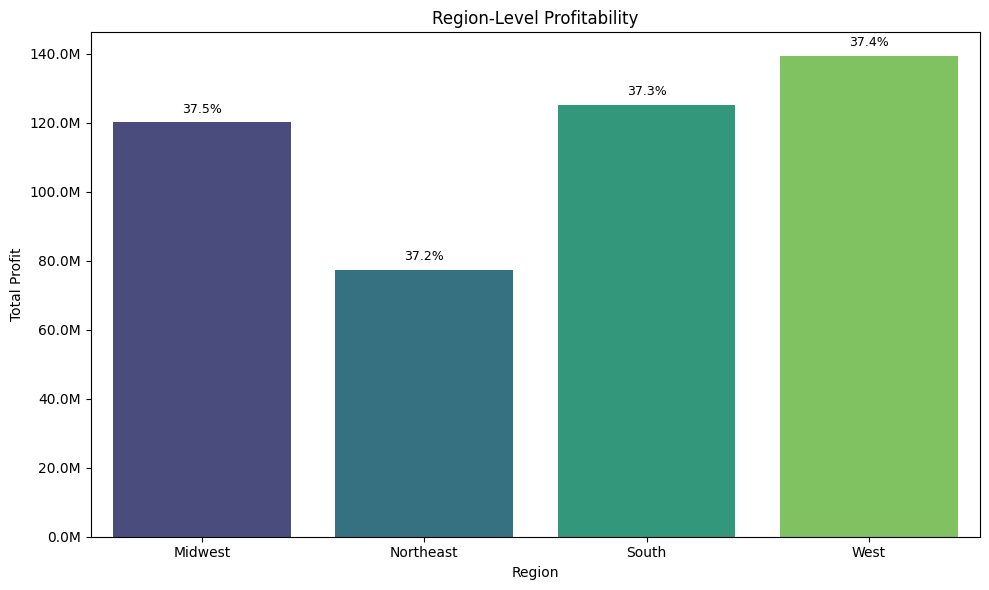

In [ ]:
region_profit = df.groupby('region').agg(total_profit=('profit', 'sum'), profit_margin_pct=('profit_margin_percentage','mean')).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='region', y='total_profit', data=region_profit, palette='viridis')

for i, bar in enumerate(ax.patches):
    margin_val = region_profit['profit_margin_pct'].iloc[i]
    ax.annotate(f'{margin_val:.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Region-Level Profitability")
plt.ticklabel_format(style='plain', axis='y') # Use plain style to avoid scientific notation

def millions_formatter(x, pos):
    return f'{x/1000000:.1f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

# Insight
# The West and South regions show the highest total profits, closely followed by the Midwest. The Northeast region has the lowest total profit, consistent with its lower revenue performance observed earlier. Interestingly, the profit margin percentages are remarkably consistent across all regions, indicating that differences in total profit are primarily driven by sales volume rather than varying profitability per sale.

## 3) Channel **Profitability**

In [ ]:
channel_profit = df.groupby('channel').agg(total_profit=('profit', 'sum'), profit_margin_pct=('profit_margin_percentage','mean')).reset_index()
channel_profit

,channel,total_profit,profit_margin_pct
0,Distributor,1.457701e+08,37.557091
1,Export,6.865458e+07,37.932704
2,Wholesale,2.473479e+08,37.087236


/tmp/ipykernel_7031/34755750.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




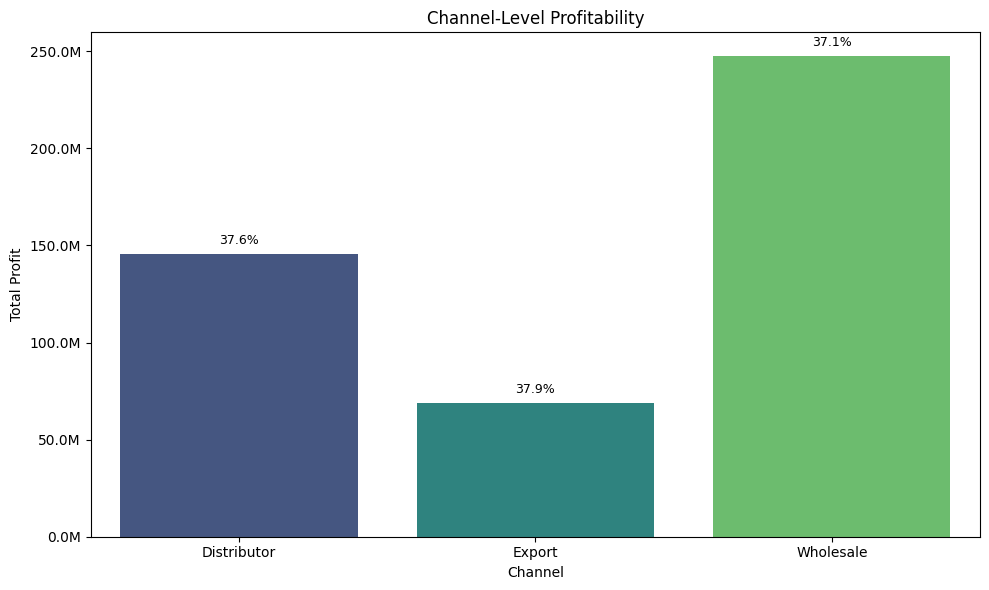

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='channel', y='total_profit', data=channel_profit, palette='viridis')

for i, bar in enumerate(ax.patches):
    margin_val = channel_profit['profit_margin_pct'].iloc[i]
    ax.annotate(f'{margin_val:.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel("Channel")
plt.ylabel("Total Profit")
plt.title("Channel-Level Profitability")
plt.ticklabel_format(style='plain', axis='y')

def millions_formatter(x, pos):
    return f'{x/1000000:.1f}M'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Channel-Level Profitability Insights and Recommendations

**Insights:**
*   **Wholesale Dominance:** The Wholesale channel is the most profitable, generating the highest total profit, consistent with its highest revenue contribution.
*   **Distributor vs. Export:** The Distributor channel generates the second-highest total profit, followed by the Export channel, which aligns with their respective revenue performances.
*   **Consistent Profit Margins:** Similar to product and region-level profitability, the profit margin percentages remain highly consistent across all channels (around 37-38%). This indicates that the differences in total profit are primarily driven by the volume of sales rather than varying profitability per individual sale within each channel.

**Recommendations:**
*   **Reinforce Wholesale Strategy:** Continue to invest in and optimize the Wholesale channel, as it is the primary driver of both revenue and profit. Explore strategies to further enhance its efficiency and market reach.
*   **Strategic Review of Distributor and Export Channels:** While the profit margins are consistent, the lower total profits for Distributor and especially Export channels suggest that strategies should focus on increasing their sales volume. For the Export channel, a thorough re-evaluation is crucial to identify and address barriers to higher sales.
*   **Leverage Cross-Channel Learnings:** Analyze successful sales strategies, product mixes, and operational efficiencies within the Wholesale channel and explore how these can be adapted and applied to the Distributor and Export channels to boost their overall performance and profit contribution.

## Conclusion: Key Findings, Data Limitations, and Recommendations

### Data Limitations
*   **Incomplete 2018 Data**: The sales data for 2018 only covers January and February, leading to an apparent sharp decline in yearly revenue for 2018. This incompleteness makes a direct year-over-year comparison for 2018 inaccurate without further data.
*   **Limited Budget Data**: Budget data was only available for 2017, restricting the budget vs. actual analysis to a single year.
*   **Homogeneous Profit Margins**: The consistent profit margins across products, regions, and channels (around 37-39%) suggest that either the cost data is highly aggregated, or specific cost variations are not captured, which might limit deeper profitability optimization strategies.

### Key Main Findings
1.  **Overall Sales Performance**: Total revenue remained relatively stable from 2014 to 2017 but showed a significant drop in the partial year 2018. Monthly trends indicate considerable fluctuations, with February 2017 being a notable low point.
2.  **Channel Dominance**: The **Wholesale channel** is the primary driver of both total revenue and total profit across all regions, significantly outperforming the Distributor and Export channels. The **Export channel** consistently delivers the lowest revenue and profit.
3.  **Regional Disparities**: The **West and South regions** are the top performers in terms of total revenue and profit, with **California** being the leading state. Conversely, the **Northeast region** consistently underperforms across almost all products and channels, despite having a significant population, suggesting untapped potential or specific regional challenges.
4.  **Product Contribution**: **Products 25 and 26** are consistently the highest revenue and profit generators, together contributing approximately 18.35% of total sales revenue. Profit margins across all products are remarkably uniform (37-39%).
5.  **Customer Segmentation**: An RFM analysis successfully segmented customers into 'Platinum', 'Gold', 'Silver', 'Bronze', and 'Churn Risk' categories, identifying top customers like 'Pixoboo Corp' based on their weighted RFM scores.
6.  **2017 Budget Overperformance**: All products significantly exceeded their 2017 budget targets, indicating either very conservative budgeting or exceptionally strong market demand and sales execution in that year.

### Key Recommendations for the Business
2.  **Strengthen the Wholesale Channel**: Given its superior performance, continue to prioritize and invest in the Wholesale channel. Explore opportunities for expansion, enhanced marketing, and improved logistics to maximize its revenue and profit contribution.
3.  **Re-evaluate and Optimize Export Channel Strategy**: Analyze the reasons for the consistent underperformance of the Export channel. This could involve market research into international demand, reassessing pricing strategies, improving global logistics, or exploring new export markets.
4.  **Develop Targeted Strategy for the Northeast Region**: Perform a deep dive into the Northeast region's challenges. Tailor marketing campaigns, sales strategies, and potentially product offerings to better suit local preferences and competitive landscapes. Consider allocating more resources or re-evaluating the effectiveness of current sales channels in this region.
5.  **Capitalize on Top-Performing Products (25 & 26)**: Continue to leverage the success of Products 25 and 26 through strategic marketing, product innovation, and expanded distribution. Analyze their success factors to potentially replicate strategies for other products.
6.  **Refine Budgeting Process**: Update the annual budgeting process to incorporate more dynamic market data, historical performance trends, and sales team insights to set more realistic yet challenging targets, moving away from potentially conservative estimates.
7.  **Implement Targeted Customer Engagement Strategies**: Utilize the RFM segmentation to develop specific strategies for each customer segment:
    *   **Platinum & Gold Customers**: Implement loyalty programs, personalized offers, and premium services to maintain high engagement and retention.
    *   **Churn Risk Customers**: Design re-engagement campaigns, special discounts, or personalized communication to reactivate these customers and prevent further churn.

In [ ]:
rfm_df.head(1)

,customer_names,order_date,Recency,order_number,revenue,Weighted_RFM_Score,Customer_Segment
0,ALK-Abello Ltd,2018-02-24,4,402,7662321.0,58.6338,Silver Customers


In [ ]:
df = df.merge(rfm_df[['customer_names', 'Weighted_RFM_Score']], on='customer_names', how='left')

In [ ]:
df.to_csv("transformed_dataset.csv")